<a href="https://colab.research.google.com/github/sugo29/Nerf_smallsizeobejects-/blob/main/Sfm_and_nerf_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ─────────────────────────────────────────────────────────
# USER CONFIGURATION — edit these paths before running
# ─────────────────────────────────────────────────────────
VIDEO_PATH = '/content/drive/MyDrive/Nerf_project/flower_video.mp4'  # <-- your video file
PROJECT_ROOT = '/content/drive/MyDrive/flower_3d_project' # <-- output folder in Drive

# Frame extraction settings
FPS = 4            # frames per second to extract (2–5 is usually sufficient)
MAX_FRAMES = 300   # cap to avoid memory issues in Colab

# Preprocessing flags (set True/False to toggle experiments)
DO_BG_REMOVAL    = True   # rembg background removal
DO_RESIZE        = True   # resize frames
TARGET_WIDTH     = 1024   # target width (height auto-scaled)
DO_FRAME_SELECT  = True   # adaptive frame selection (sharpness-based)
BLUR_THRESHOLD   = 0.0  # Laplacian variance threshold (lower = reject more blurry)

# Training settings
NERF_STEPS       = 30000
SPLAT_STEPS      = 30000

import os
os.makedirs(PROJECT_ROOT, exist_ok=True)

# Sub-directories
RAW_FRAMES_DIR    = os.path.join(PROJECT_ROOT, 'frames_raw')
PROC_FRAMES_DIR   = os.path.join(PROJECT_ROOT, 'frames_processed')
COLMAP_DIR        = os.path.join(PROJECT_ROOT, 'colmap')
NERF_DIR          = os.path.join(PROJECT_ROOT, 'nerf_output')
SPLAT_DIR         = os.path.join(PROJECT_ROOT, 'splat_output')
EVAL_DIR          = os.path.join(PROJECT_ROOT, 'evaluation')

for d in [RAW_FRAMES_DIR, PROC_FRAMES_DIR, COLMAP_DIR, NERF_DIR, SPLAT_DIR, EVAL_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted and project directories created.')
print(f'   Project root : {PROJECT_ROOT}')
print(f'   Video source : {VIDEO_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and project directories created.
   Project root : /content/drive/MyDrive/flower_3d_project
   Video source : /content/drive/MyDrive/Nerf_project/flower_video.mp4


1. Install Dependencies

In [ ]:
# ── System packages ──────────────────────────────────────
!apt-get update -qq
!apt-get install -y -qq \
    ffmpeg \
    colmap \
    libboost-all-dev \
    libfreeimage-dev \
    libgflags-dev \
    libatlas-base-dev \
    libsuitesparse-dev \
    imagemagick \
    > /dev/null 2>&1
print(' System packages installed.')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
 System packages installed.


In [ ]:
# ── Python packages ───────────────────────────────────────
!pip install -q \
    nerfstudio \
    rembg[gpu] \
    opencv-python-headless \
    scikit-image \
    lpips \
    torch torchvision \
    pillow \
    tqdm \
    matplotlib \
    pandas \
    seaborn \
    open3d
print('Python packages installed.')

Python packages installed.


In [ ]:
# ── Verify GPU ────────────────────────────────────────────
import torch
assert torch.cuda.is_available(), '❌ GPU not available — change runtime to GPU!'
print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ GPU: Tesla T4
   VRAM: 15.6 GB


In [ ]:
import subprocess, glob, shutil

def extract_frames(video_path, output_dir, fps=2, max_frames=300):
    """Extract frames from video at given FPS using FFmpeg."""
    os.makedirs(output_dir, exist_ok=True)

    # Get video duration
    result = subprocess.run(
        ['ffprobe', '-v', 'error', '-show_entries', 'format=duration',
         '-of', 'default=noprint_wrappers=1:nokey=1', video_path],
        capture_output=True, text=True
    )
    duration = float(result.stdout.strip())
    total_at_fps = int(duration * fps)

    # If total frames exceed max, reduce fps automatically
    if total_at_fps > max_frames:
        fps = max_frames / duration
        print(f'⚠️  Capping fps to {fps:.2f} to stay within {max_frames} frames.')

    out_pattern = os.path.join(output_dir, 'frame_%05d.jpg')
    cmd = [
        'ffmpeg', '-i', video_path,
        '-vf', f'fps={fps}',
        '-q:v', '2',          # high quality JPEG
        '-start_number', '0',
        out_pattern, '-y'
    ]
    subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    frames = sorted(glob.glob(os.path.join(output_dir, '*.jpg')))
    print(f'✅ Extracted {len(frames)} frames → {output_dir}')
    return frames


raw_frames = extract_frames(VIDEO_PATH, RAW_FRAMES_DIR, fps=FPS, max_frames=MAX_FRAMES)

✅ Extracted 104 frames → /content/drive/MyDrive/flower_3d_project/frames_raw


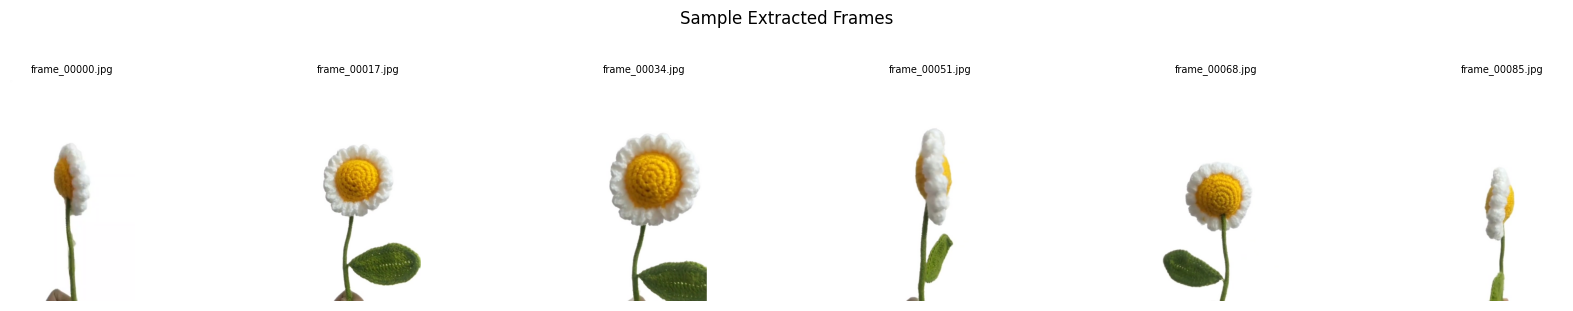

Total frames extracted: 104


In [ ]:
# ── Quick visual check: show 6 sample frames ─────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

sample = raw_frames[::max(1, len(raw_frames)//6)][:6]
fig, axes = plt.subplots(1, len(sample), figsize=(18, 3))
for ax, f in zip(axes, sample):
    ax.imshow(mpimg.imread(f))
    ax.set_title(os.path.basename(f), fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Extracted Frames', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'sample_frames.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Total frames extracted: {len(raw_frames)}')

📊 Analyzing Laplacian variance of all frames...


Computing sharpness: 100%|██████████| 104/104 [00:00<00:00, 107.15it/s]



📈 Laplacian Variance Statistics:
   Min   : 5.05
   Max   : 36.31
   Mean  : 18.23
   Median: 17.78
   Std   : 8.26

💡 RECOMMENDATION: Set BLUR_THRESHOLD to ~10.9 (25th percentile)
   This keeps ~75% of frames and removes blurriest 25%.


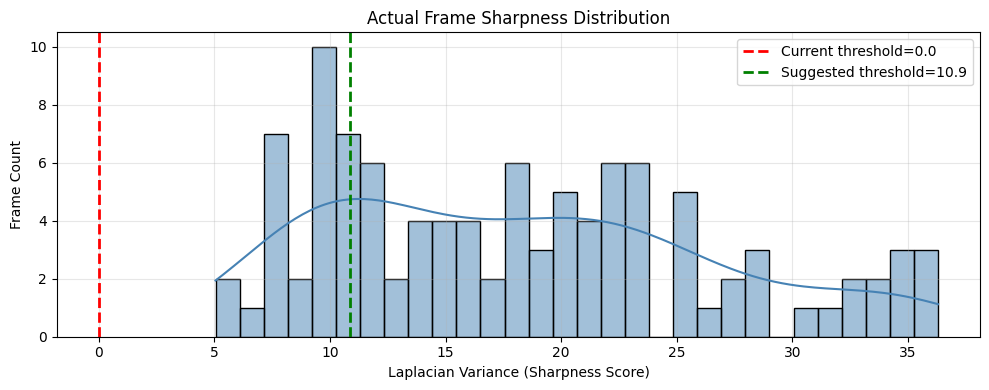

In [ ]:
import cv2
from tqdm import tqdm
import numpy as np # Added for np.array, np.median, np.percentile
import matplotlib.pyplot as plt # Added for plotting
import seaborn as sns # Added for histplot

print('📊 Analyzing Laplacian variance of all frames...')
all_scores = []
# For diagnostic purposes, analyze all raw frames to see the full distribution
for f in tqdm(raw_frames, desc='Computing sharpness'):
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Warning: Could not read image {f}. Skipping.")
        continue
    score = cv2.Laplacian(img, cv2.CV_64F).var()
    all_scores.append(score)

all_scores = np.array(all_scores)

if len(all_scores) == 0:
    print("\n⚠️ No frames were processed to calculate Laplacian variance. 'all_scores' array is empty.")
    print("This might happen if 'raw_frames' was empty, or images could not be read. Please check your video path and frame extraction.")
else:
    print(f'\n📈 Laplacian Variance Statistics:')
    print(f'   Min   : {all_scores.min():.2f}')
    print(f'   Max   : {all_scores.max():.2f}')
    print(f'   Mean  : {all_scores.mean():.2f}')
    print(f'   Median: {np.median(all_scores):.2f}')
    print(f'   Std   : {all_scores.std():.2f}')
    print(f'\n💡 RECOMMENDATION: Set BLUR_THRESHOLD to ~{np.percentile(all_scores, 25):.1f} (25th percentile)')
    print(f'   This keeps ~75% of frames and removes blurriest 25%.')

    # Plot distribution
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(all_scores, bins=30, kde=True, ax=ax, color='steelblue')
    # Ensure BLUR_THRESHOLD is defined from previous cells
    ax.axvline(BLUR_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Current threshold={BLUR_THRESHOLD}')
    ax.axvline(np.percentile(all_scores, 25), color='green', linestyle='--', linewidth=2, label=f'Suggested threshold={np.percentile(all_scores, 25):.1f}')
    ax.set_xlabel('Laplacian Variance (Sharpness Score)')
    ax.set_ylabel('Frame Count')
    ax.set_title('Actual Frame Sharpness Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
import cv2
from PIL import Image
from tqdm import tqdm

# ── 3a. Sharpness-based frame selection ──────────────────
def laplacian_variance(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(img, cv2.CV_64F).var()

def select_sharp_frames(frames, threshold=100.0):
    sharp, rejected = [], []
    scores = {}
    for f in tqdm(frames, desc='Sharpness filter'):
        score = laplacian_variance(f)
        scores[f] = score
        if score >= threshold:
            sharp.append(f)
        else:
            rejected.append(f)
    print(f'  Sharp frames  : {len(sharp)}')
    print(f'  Blurry rejected: {len(rejected)} (threshold={threshold})')
    return sharp, scores

if DO_FRAME_SELECT:
    selected_frames, sharpness_scores = select_sharp_frames(raw_frames, BLUR_THRESHOLD)
else:
    selected_frames = raw_frames
    sharpness_scores = {f: laplacian_variance(f) for f in raw_frames}

print(f'✅ Frames after selection: {len(selected_frames)}')

Sharpness filter: 100%|██████████| 104/104 [00:00<00:00, 133.09it/s]

  Sharp frames  : 104
  Blurry rejected: 0 (threshold=0.0)
✅ Frames after selection: 104


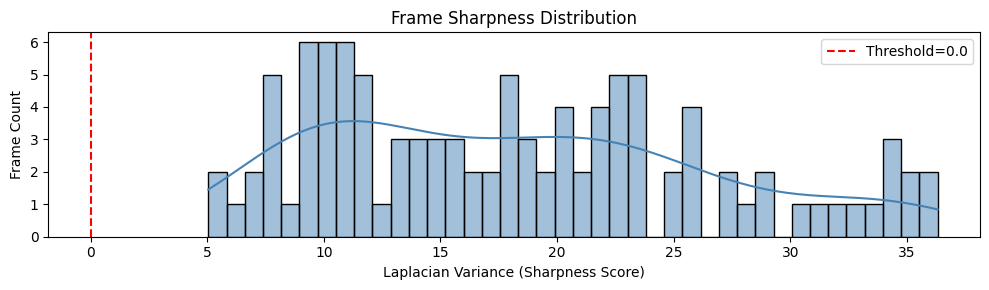

In [ ]:
# ── 3b. Plot sharpness distribution ──────────────────────
import seaborn as sns
import pandas as pd

scores = list(sharpness_scores.values())
fig, ax = plt.subplots(figsize=(10, 3))
sns.histplot(scores, bins=40, kde=True, ax=ax, color='steelblue')
ax.axvline(BLUR_THRESHOLD, color='red', linestyle='--', label=f'Threshold={BLUR_THRESHOLD}')
ax.set_xlabel('Laplacian Variance (Sharpness Score)')
ax.set_ylabel('Frame Count')
ax.set_title('Frame Sharpness Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'sharpness_distribution.png'), dpi=150)
plt.show()

In [ ]:
# ── 3c. Resize frames ─────────────────────────────────────
def resize_frame(img_path, out_path, target_width):
    img = Image.open(img_path)
    w, h = img.size
    aspect = h / w
    new_h = int(target_width * aspect)
    img_resized = img
    img_resized.save(out_path, quality=95)

if DO_RESIZE:
    RESIZE_DIR = os.path.join(PROJECT_ROOT, 'frames_resized')
    os.makedirs(RESIZE_DIR, exist_ok=True)
    for f in tqdm(selected_frames, desc='Resizing'):
        out = os.path.join(RESIZE_DIR, os.path.basename(f))
        resize_frame(f, out, TARGET_WIDTH)
    selected_frames = sorted(glob.glob(os.path.join(RESIZE_DIR, '*.jpg')))
    print(f'✅ Resized {len(selected_frames)} frames to width={TARGET_WIDTH}px → {RESIZE_DIR}')

    # Verify new dimensions
    sample_img = Image.open(selected_frames[0])
    print(f'   Sample size: {sample_img.size[0]}x{sample_img.size[1]} px')

Resizing: 100%|██████████| 104/104 [00:02<00:00, 41.21it/s]

✅ Resized 104 frames to width=1024px → /content/drive/MyDrive/flower_3d_project/frames_resized
   Sample size: 1024x1820 px


In [ ]:
# ── 3d. Background removal using rembg ───────────────────
# rembg uses a U²-Net model to segment foreground.
# Output: RGBA PNG with transparent background.
# These RGBA images can be used as masks in Nerfstudio.

# Fix for numpy/scipy incompatibility with rembg's dependencies
# Uninstall rembg first to clear its dependencies, then force stable numpy/scipy, then reinstall rembg
#!pip uninstall -y rembg # Uninstall rembg first
#!pip uninstall -y numpy scipy # Force uninstall to clear old versions/configs
#!pip install numpy==1.26.4 scipy==1.12.0 # Install specific stable versions known for compatibility
#!pip install rembg[gpu] # Reinstall rembg after compatible numpy/scipy are in place

if DO_BG_REMOVAL:
    #from rembg import remove as rembg_remove
    from PIL import Image # Ensure PIL is imported here as it's used directly

    BG_REMOVED_DIR = os.path.join(PROJECT_ROOT, 'frames_nobg')
    MASK_DIR       = os.path.join(PROJECT_ROOT, 'masks')
    os.makedirs(BG_REMOVED_DIR, exist_ok=True)
    os.makedirs(MASK_DIR, exist_ok=True)

    for f in tqdm(selected_frames, desc='Background removal'):
        with open(f, 'rb') as inp:
            data = inp.read()
        output = data  # returns PNG bytes (RGBA)
        base = os.path.splitext(os.path.basename(f))[0]

        # Save RGBA image
        rgba_path = os.path.join(BG_REMOVED_DIR, base + '.png')
        with open(rgba_path, 'wb') as out:
            out.write(output)

        # Extract and save binary mask (alpha channel)
        rgba_img = Image.open(rgba_path)
        mask = rgba_img.split()[-1]   # alpha channel
        mask_bin = mask.point(lambda p: 255 if p > 128 else 0)
        mask_bin.save(os.path.join(MASK_DIR, base + '_mask.png'))

    print(f'✅ Background removed for {len(selected_frames)} frames.')
    print(f'   RGBA images → {BG_REMOVED_DIR}')
    print(f'   Binary masks → {MASK_DIR}')

Background removal: 100%|██████████| 104/104 [00:05<00:00, 18.80it/s]

✅ Background removed for 104 frames.
   RGBA images → /content/drive/MyDrive/flower_3d_project/frames_nobg
   Binary masks → /content/drive/MyDrive/flower_3d_project/masks


In [ ]:
# ── 3e. Specular/Reflective Region Detection ─────────────
# High-intensity saturated pixels indicate specular highlights.
# These can be passed to Nerfstudio as uncertainty masks.

def detect_specular_mask(img_path, brightness_thresh=230, save_path=None):
    """
    Detect specular highlights using brightness + low-saturation heuristic.
    Very bright, near-white pixels = specular.
    """
    img_bgr = cv2.imread(img_path)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # High value (bright), low saturation (white/silver = specular)
    mask_bright = hsv[:,:,2] > brightness_thresh
    mask_lowsat = hsv[:,:,1] < 40
    specular_mask = (mask_bright & mask_lowsat).astype(np.uint8) * 255

    # Dilate to cover specular halos
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    specular_mask = cv2.dilate(specular_mask, kernel, iterations=2)

    if save_path:
        cv2.imwrite(save_path, img_bgr)
    return specular_mask

SPECULAR_DIR = os.path.join(PROJECT_ROOT, 'specular_masks')
os.makedirs(SPECULAR_DIR, exist_ok=True)

specular_coverage = []
for f in tqdm(selected_frames[:50], desc='Specular detection (sample)'):
    base = os.path.splitext(os.path.basename(f))[0]
    save_p = os.path.join(SPECULAR_DIR, base + '_specular.png')
    sm = detect_specular_mask(f, save_path=save_p)
    coverage = sm.mean() / 255.0
    specular_coverage.append(coverage)

print(f'✅ Specular analysis on {len(specular_coverage)} frames:')
print(f'   Mean specular coverage : {np.mean(specular_coverage)*100:.1f}%')
print(f'   Max specular coverage  : {np.max(specular_coverage)*100:.1f}%')
print(f'   Masks saved → {SPECULAR_DIR}')

Specular detection (sample): 100%|██████████| 50/50 [00:04<00:00, 10.82it/s]

✅ Specular analysis on 50 frames:
   Mean specular coverage : 80.8%
   Max specular coverage  : 93.1%
   Masks saved → /content/drive/MyDrive/flower_3d_project/specular_masks


ValueError: NumPy boolean array indexing assignment cannot assign 3 input values to the 5243811 output values where the mask is true

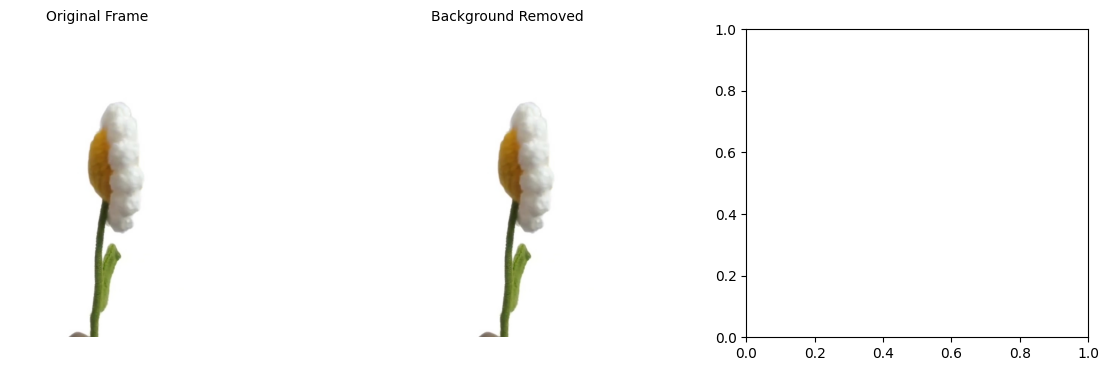

In [ ]:
# ── 3f. Preprocessing summary visualisation ──────────────
idx = len(selected_frames) // 2
original  = np.array(Image.open(selected_frames[idx]).convert('RGB'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(original)
axes[0].set_title('Original Frame', fontsize=10)
axes[0].axis('off')

if DO_BG_REMOVAL:
    bg_files = sorted(glob.glob(os.path.join(BG_REMOVED_DIR, '*.png')))
    nobg_img = np.array(Image.open(bg_files[idx]).convert('RGBA'))
    # Composite over white for display
    bg = np.ones_like(nobg_img[:,:,:3]) * 255
    alpha = nobg_img[:,:,3:] / 255.0
    composite = (nobg_img[:,:,:3] * alpha + bg * (1 - alpha)).astype(np.uint8)
    axes[1].imshow(composite)
    axes[1].set_title('Background Removed', fontsize=10)
else:
    axes[1].imshow(original)
    axes[1].set_title('(bg removal disabled)', fontsize=10)
axes[1].axis('off')

spec_files = sorted(glob.glob(os.path.join(SPECULAR_DIR, '*.png')))
if spec_files:
    spec_viz = np.array(Image.open(spec_files[min(idx,len(spec_files)-1)]))
    overlay = original.copy()
    overlay[spec_viz > 128] = [255, 0, 0]  # red = specular
    axes[2].imshow(overlay)
    axes[2].set_title('Specular Regions (red)', fontsize=10)
else:
    axes[2].imshow(original)
axes[2].axis('off')

plt.suptitle('Preprocessing Pipeline Comparison', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'preprocessing_comparison.png'), dpi=150)
plt.show()

In [ ]:
# ── 3g. Copy final processed frames to PROC_FRAMES_DIR ───
# Use background-removed images if available, else resized.
import shutil

if DO_BG_REMOVAL:
    source_frames = sorted(glob.glob(os.path.join(BG_REMOVED_DIR, '*.png')))
    # Convert RGBA → RGB JPEG for COLMAP compatibility
    for f in tqdm(source_frames, desc='Convert RGBA→RGB for COLMAP'):
        img = Image.open(f).convert('RGBA')
        bg = Image.new('RGB', img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        out = os.path.join(PROC_FRAMES_DIR, os.path.splitext(os.path.basename(f))[0] + '.jpg')
        bg.save(out, quality=95)
else:
    for f in selected_frames:
        shutil.copy(f, PROC_FRAMES_DIR)

proc_frames = sorted(glob.glob(os.path.join(PROC_FRAMES_DIR, '*.jpg')))
print(f'✅ Processed frames ready: {len(proc_frames)} → {PROC_FRAMES_DIR}')

Convert RGBA→RGB for COLMAP: 100%|██████████| 104/104 [00:04<00:00, 22.75it/s]

✅ Processed frames ready: 104 → /content/drive/MyDrive/flower_3d_project/frames_processed


4. Structure-from-Motion (COLMAP)

Pipeline:
1. Feature extraction (SIFT)
2. Sequential matching (appropriate for 360° video)
3. Sparse reconstruction + bundle adjustment
4. Export camera poses

In [ ]:
import subprocess

COLMAP_DB      = os.path.join(COLMAP_DIR, 'database.db')
COLMAP_SPARSE  = os.path.join(COLMAP_DIR, 'sparse')
COLMAP_DENSE   = os.path.join(COLMAP_DIR, 'dense')
os.makedirs(COLMAP_SPARSE, exist_ok=True)

def run_colmap(cmd_args, step_name):
    print(f'\n▶ COLMAP: {step_name}...')
    env = os.environ.copy()
    env['QT_QPA_PLATFORM'] = 'offscreen'
    result = subprocess.run(
        ['colmap'] + cmd_args,
        capture_output=True, text=True,
        env=env
    )
    if result.returncode != 0:
        print(f'  STDERR: {result.stderr[-500:]}')
        raise RuntimeError(f'COLMAP step failed: {step_name}')
    print(f'  ✅ {step_name} complete.')
    return result

# ── Step 1: Feature Extraction (SIFT) ────────────────────
run_colmap([
    'feature_extractor',
    '--database_path', COLMAP_DB,
    '--image_path',    PROC_FRAMES_DIR,
    '--ImageReader.single_camera', '1',
    '--SiftExtraction.use_gpu', '0',
    '--SiftExtraction.max_num_features', '8192',
    '--SiftExtraction.max_image_size', str(TARGET_WIDTH),
], 'SIFT Feature Extraction')


▶ COLMAP: SIFT Feature Extraction...
  ✅ SIFT Feature Extraction complete.


CompletedProcess(args=['colmap', 'feature_extractor', '--database_path', '/content/drive/MyDrive/flower_3d_project/colmap/database.db', '--image_path', '/content/drive/MyDrive/flower_3d_project/frames_processed', '--ImageReader.single_camera', '1', '--SiftExtraction.use_gpu', '0', '--SiftExtraction.max_num_features', '8192', '--SiftExtraction.max_image_size', '1024'], returncode=0, stdout='\n==============================================================================\nFeature extraction\n==============================================================================\n\nProcessed file [1/104]\n  Name:            frame_00000.jpg\n  SKIP: Features for image already extracted.\nProcessed file [2/104]\n  Name:            frame_00001.jpg\n  SKIP: Features for image already extracted.\nProcessed file [3/104]\n  Name:            frame_00002.jpg\n  SKIP: Features for image already extracted.\nProcessed file [4/104]\n  Name:            frame_00003.jpg\n  SKIP: Features for image already extract

In [ ]:
# ── Step 2: Sequential Feature Matching ──────────────────
# Sequential matching is optimal for video input (frame i matches i±overlap)
run_colmap([
    'sequential_matcher',
    '--database_path', COLMAP_DB,
    '--SiftMatching.use_gpu', '0',
    '--SequentialMatching.overlap', '10',     # match ±10 adjacent frames
    '--SequentialMatching.loop_detection', '0', # Disable loop detection to debug crash
    '--SequentialMatching.loop_detection_period', '10',
    '--SequentialMatching.loop_detection_num_images', '50',
], 'Sequential Feature Matching')


▶ COLMAP: Sequential Feature Matching...
  ✅ Sequential Feature Matching complete.


CompletedProcess(args=['colmap', 'sequential_matcher', '--database_path', '/content/drive/MyDrive/flower_3d_project/colmap/database.db', '--SiftMatching.use_gpu', '0', '--SequentialMatching.overlap', '10', '--SequentialMatching.loop_detection', '0', '--SequentialMatching.loop_detection_period', '10', '--SequentialMatching.loop_detection_num_images', '50'], returncode=0, stdout='\n==============================================================================\nSequential feature matching\n==============================================================================\n\nMatching image [1/104] in 0.079s\nMatching image [2/104] in 0.136s\nMatching image [3/104] in 0.081s\nMatching image [4/104] in 0.110s\nMatching image [5/104] in 0.147s\nMatching image [6/104] in 0.152s\nMatching image [7/104] in 0.121s\nMatching image [8/104] in 0.142s\nMatching image [9/104] in 0.121s\nMatching image [10/104] in 0.181s\nMatching image [11/104] in 0.126s\nMatching image [12/104] in 0.102s\nMatching image 

In [ ]:
# ── Step 3: Sparse Reconstruction + Bundle Adjustment ────
run_colmap([
    'mapper',
    '--database_path',   COLMAP_DB,
    '--image_path',      PROC_FRAMES_DIR,
    '--output_path',     COLMAP_SPARSE,
    '--Mapper.num_threads', '4',
    '--Mapper.init_min_tri_angle', '4',
    '--Mapper.ba_refine_focal_length', '1',
    '--Mapper.ba_refine_principal_point', '0',
    '--Mapper.ba_refine_extra_params', '1',
], 'Sparse Reconstruction (Mapper + BA)')


▶ COLMAP: Sparse Reconstruction (Mapper + BA)...
  ✅ Sparse Reconstruction (Mapper + BA) complete.


CompletedProcess(args=['colmap', 'mapper', '--database_path', '/content/drive/MyDrive/flower_3d_project/colmap/database.db', '--image_path', '/content/drive/MyDrive/flower_3d_project/frames_processed', '--output_path', '/content/drive/MyDrive/flower_3d_project/colmap/sparse', '--Mapper.num_threads', '4', '--Mapper.init_min_tri_angle', '4', '--Mapper.ba_refine_focal_length', '1', '--Mapper.ba_refine_principal_point', '0', '--Mapper.ba_refine_extra_params', '1'], returncode=0, stdout='\n==============================================================================\nLoading database\n==============================================================================\n\nLoading cameras... 2 in 0.000s\nLoading matches... 279 in 0.009s\nLoading images... 104 in 0.017s (connected 99)\nBuilding correspondence graph... in 0.024s (ignored 0)\n\nElapsed time: 0.001 [minutes]\n\n\n==============================================================================\nFinding good initial image pair\n==========

In [ ]:
# ── Step 4: Model Analysis & Reprojection Error ───────────
import re

def parse_colmap_stats(sparse_dir):
    """Parse COLMAP model stats and reprojection error."""
    model_dir = os.path.join(sparse_dir, '0')
    if not os.path.exists(model_dir):
        models = sorted(os.listdir(sparse_dir))
        if not models:
            raise FileNotFoundError('No COLMAP models found in sparse dir!')
        model_dir = os.path.join(sparse_dir, models[0])

    result = subprocess.run(
        ['colmap', 'model_analyzer', '--path', model_dir],
        capture_output=True, text=True
    )
    stats_text = result.stdout + result.stderr

    stats = {}
    for key, pattern in [
        ('num_images',    r'Cameras:\s*(\d+)'),
        ('num_points3d',  r'Points:\s*([\d,]+)'),
        ('reproj_error',  r'Mean reprojection error:\s*([\d.]+)'),
        ('track_length',  r'Mean track length:\s*([\d.]+)'),
        ('obs_per_img',   r'Mean observations per image:\s*([\d.]+)'),
    ]:
        m = re.search(pattern, stats_text)
        if m:
            stats[key] = float(m.group(1).replace(',',''))

    return stats, model_dir

colmap_stats, model_dir = parse_colmap_stats(COLMAP_SPARSE)

print('\n📊 COLMAP Reconstruction Statistics:')
print(f'   Registered cameras    : {colmap_stats.get("num_images","N/A")}')
print(f'   3D points             : {colmap_stats.get("num_points3d","N/A")}')
print(f'   Mean reprojection err : {colmap_stats.get("reproj_error","N/A")} px')
print(f'   Mean track length     : {colmap_stats.get("track_length","N/A")}')
print(f'   Observations/image    : {colmap_stats.get("obs_per_img","N/A")}')


📊 COLMAP Reconstruction Statistics:
   Registered cameras    : 2.0
   3D points             : 1997.0
   Mean reprojection err : 0.934666 px
   Mean track length     : 5.48673
   Observations/image    : 332.030303


In [ ]:
# ── Step 5: Export to text format (for inspection) ────────
COLMAP_TEXT_DIR = os.path.join(COLMAP_DIR, 'sparse_text')
os.makedirs(COLMAP_TEXT_DIR, exist_ok=True)

run_colmap([
    'model_converter',
    '--input_path',  model_dir,
    '--output_path', COLMAP_TEXT_DIR,
    '--output_type', 'TXT'
], 'Export sparse model to TXT')

# Save COLMAP stats for later comparison
import json
with open(os.path.join(EVAL_DIR, 'colmap_stats.json'), 'w') as f:
    json.dump(colmap_stats, f, indent=2)
print('✅ COLMAP stats saved.')


▶ COLMAP: Export sparse model to TXT...
  ✅ Export sparse model to TXT complete.
✅ COLMAP stats saved.


Loaded 1997 3D points from COLMAP sparse model.


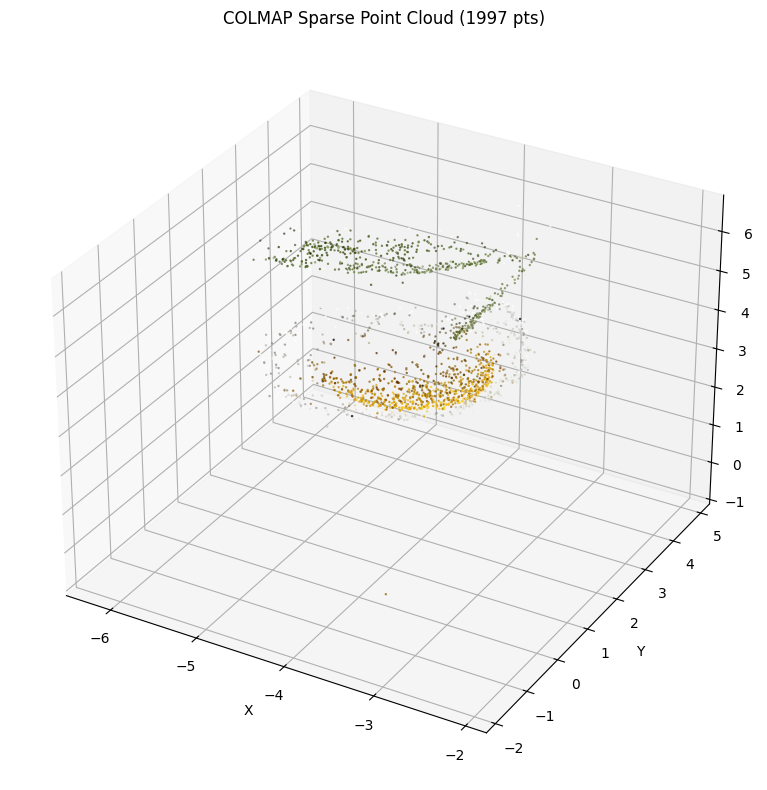

In [ ]:
# ── 3D Point Cloud Visualisation ─────────────────────────
import open3d as o3d

def load_colmap_points(text_dir):
    """Load 3D points from COLMAP points3D.txt"""
    pts_file = os.path.join(text_dir, 'points3D.txt')
    points, colors = [], []
    with open(pts_file) as f:
        for line in f:
            if line.startswith('#') or len(line.strip()) == 0:
                continue
            parts = line.split()
            if len(parts) < 7:
                continue
            x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            r, g, b = int(parts[4]), int(parts[5]), int(parts[6])
            points.append([x, y, z])
            colors.append([r/255, g/255, b/255])
    return np.array(points), np.array(colors)

points, colors = load_colmap_points(COLMAP_TEXT_DIR)
print(f'Loaded {len(points)} 3D points from COLMAP sparse model.')

# Plot with matplotlib (3D scatter)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
# Sample for speed
idx_sample = np.random.choice(len(points), min(5000, len(points)), replace=False)
ax.scatter(points[idx_sample,0], points[idx_sample,1], points[idx_sample,2],
           c=colors[idx_sample], s=0.5, alpha=0.7)
ax.set_title(f'COLMAP Sparse Point Cloud ({len(points)} pts)', fontsize=12)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'colmap_pointcloud.png'), dpi=150)
plt.show()

In [ ]:
NS_DATA_DIR = os.path.join(PROJECT_ROOT, 'ns_data')
os.makedirs(NS_DATA_DIR, exist_ok=True)

# Convert COLMAP sparse model to nerfstudio format
!ns-process-data images \
    --data {PROC_FRAMES_DIR} \
    --output-dir {NS_DATA_DIR} \
    --colmap-model-path {model_dir} \
    --num-downscales 0 \
    --skip-colmap  # reuse our existing COLMAP results

print('✅ Nerfstudio dataset prepared.')
!ls {NS_DATA_DIR}

Traceback (most recent call last):
  File "/usr/local/bin/ns-process-data", line 5, in <module>
    from nerfstudio.scripts.process_data import entrypoint
  File "/usr/local/lib/python3.12/dist-packages/nerfstudio/scripts/process_data.py", line 28, in <module>
    from nerfstudio.process_data import (
  File "/usr/local/lib/python3.12/dist-packages/nerfstudio/process_data/metashape_utils.py", line 23, in <module>
    import open3d as o3d
  File "/usr/local/lib/python3.12/dist-packages/open3d/__init__.py", line 163, in <module>
    import open3d.ml
  File "/usr/local/lib/python3.12/dist-packages/open3d/ml/__init__.py", line 16, in <module>
    from . import datasets
  File "/usr/local/lib/python3.12/dist-packages/open3d/ml/datasets.py", line 15, in <module>
    from open3d._ml3d.datasets import *
  File "/usr/local/lib/python3.12/dist-packages/open3d/_ml3d/datasets/__init__.py", line 3, in <module>
    from .semantickitti import SemanticKITTI
  File "/usr/local/lib/python3.12/dist-packa

In [ ]:
# Alternatively, if ns-process-data --skip-colmap fails,
# convert directly from COLMAP using ns-process-data colmap subcommand:

# !ns-process-data colmap \
#     --data {PROC_FRAMES_DIR} \
#     --output-dir {NS_DATA_DIR}

# Verify transforms.json was created
transforms_path = os.path.join(NS_DATA_DIR, 'transforms.json')
assert os.path.exists(transforms_path), 'transforms.json not found! Check ns-process-data.'

with open(transforms_path) as f:
    transforms = json.load(f)

print(f'✅ transforms.json loaded:')
print(f'   Camera model : {transforms.get("camera_model", "N/A")}')
print(f'   Num frames   : {len(transforms.get("frames", []))}')
print(f'   fl_x         : {transforms.get("fl_x", "N/A")}')
print(f'   fl_y         : {transforms.get("fl_y", "N/A")}')

AssertionError: transforms.json not found! Check ns-process-data.